## Notebook 4 — Threshold & Evaluation

## 1. Imports and Load Data

load the same processed CSV files from preprocessing and both saved models

In [28]:
import pandas as pd # data loading and manipulation
import numpy as np # numerical operations
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns  # styled plotting
import os # used to build file paths
import joblib # saving and loading models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # 2x2 table of TP, TN, FP, FN
from sklearn.metrics import precision_recall_curve, auc # precision and recall at every possible threshold
from sklearn.metrics import roc_curve, roc_auc_score # true positive rate vs false positive rate at every threshold
from sklearn.metrics import classification_report # precision, recall, F1 in one table
from sklearn.metrics import precision_score, recall_score, f1_score # used in threshold loop and comparison table

## 2. Load Processed Data and Saved Models

loaded the test set only as models were saved in Notebook 3

`.squeeze()` converts the single-column y DataFrames back into a Series

A Series is a single column of data

In [29]:
# Load the four processed CSV files
# X = features (30 columns: V1-V28, Log_Amount, Hour)
# y = target (0 = legitimate, 1 = fraud)
X_train = pd.read_csv(os.path.join('..', 'data', 'processed', 'X_train.csv'))
y_train = pd.read_csv(os.path.join('..', 'data', 'processed', 'y_train.csv')).squeeze()

X_test = pd.read_csv(os.path.join('..', 'data', 'processed', 'X_test.csv'))
y_test = pd.read_csv(os.path.join('..', 'data', 'processed', 'y_test.csv')).squeeze()

# Load both saved models
lr = joblib.load(os.path.join('..', 'models', 'logistic_regression.pkl'))
rf = joblib.load(os.path.join('..', 'models', 'random_forest.pkl'))

## 3. Generate Predictions

generate two types of output from each model
 - `predict()` predictions (0 or 1) using the default threshold of 0.5

 - `predict_proba()` probability scores between 0 and 1

 - `[:, 1]` selects the fraud probability column only

 - `predict_proba()` returns two columns probability of class 0 and probability of class 1


In [ ]:
# predictions using default threshold of 0.5
predict_lr_test = lr.predict(X_test)
predict_rf_test = rf.predict(X_test)

# predict_proba returns [prob_legitimate, prob_fraud] for each transaction
# [:, 1] selects the fraud probability column only
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

## 4. Confusion Matrices

confusion matrix shows exactly what the model got right and wrong

| | Predicted Legitimate | Predicted Fraud |
|---|---|---|
| **Actual Legitimate** | TN — correctly identified legitimate | FP — false alarm |
| **Actual Fraud** | FN — missed fraud | TP — correctly caught fraud |

most important for this project is FN (False Negatives)** — these are real fraud
cases the model failed to catch

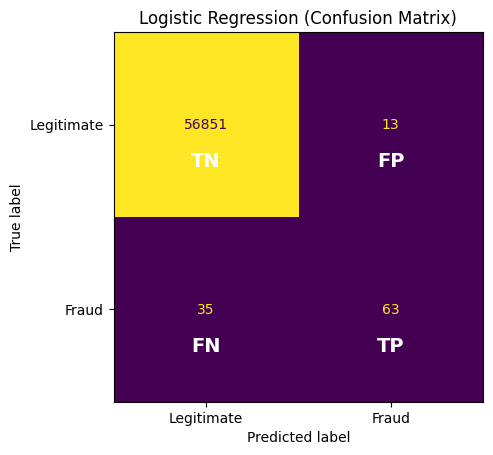

Logistic Regression — Caught: 63 fraud | Missed: 35 fraud | False alarms: 13


In [31]:
# Logistic Regression confusion matrix
# confusion_matrix(actual, predicted) 
confusion_matrix_lr = confusion_matrix(y_test, predict_lr_test)
display_cm = ConfusionMatrixDisplay(confusion_matrix_lr, display_labels=['Legitimate', 'Fraud'])
display_cm.plot(colorbar=False)
plt.title('Logistic Regression (Confusion Matrix)')

# Add TP/TN/FP/FN labels to each cell
plt.text(0, 0.2, 'TN', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(1, 0.2, 'FP', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(0, 1.2, 'FN', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(1, 1.2, 'TP', ha='center', va='center', color='white', fontsize=14, fontweight='bold')

plt.show()

tn, fp, fn, tp = confusion_matrix_lr.ravel()
print(f'Logistic Regression — Caught: {tp} fraud | Missed: {fn} fraud | False alarms: {fp}')

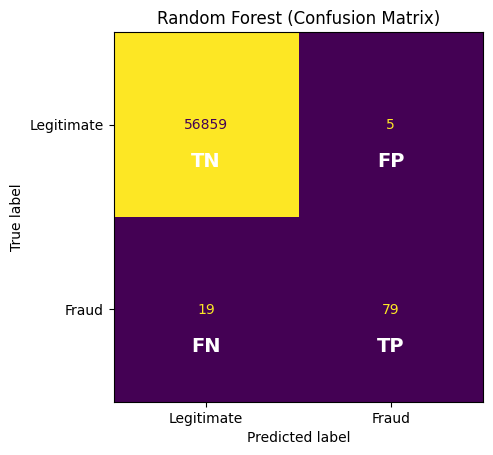

Random Forest — Caught: 79 fraud | Missed: 19 fraud | False alarms: 5


In [32]:
# Random Forest confusion matrix
confusion_matrix_rf = confusion_matrix(y_test, predict_rf_test)
display_cm = ConfusionMatrixDisplay(confusion_matrix_rf, display_labels=['Legitimate', 'Fraud'])
display_cm.plot(colorbar=False)
plt.title('Random Forest (Confusion Matrix)')

# Add TP/TN/FP/FN labels to each cell
plt.text(0, 0.2, 'TN', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(1, 0.2, 'FP', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(0, 1.2, 'FN', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.text(1, 1.2, 'TP', ha='center', va='center', color='white', fontsize=14, fontweight='bold')

plt.show()

tn, fp, fn, tp = confusion_matrix_rf.ravel()
print(f'Random Forest — Caught: {tp} fraud | Missed: {fn} fraud | False alarms: {fp}')

## 5. Precision-Recall Curve

shows the tradeoff between precision and recall at every possible threshold

**Why PR curve and not just ROC?**
PR curve focuses specifically on how well the model handles the rare fraud class
imbalanced datasets ROC can look good because it is influenced by the large number
of legitimate transaction

**AUC (Area Under the Curve)**
summarises the curve as a single number
Higher AUC = better overall performance across all thresholds


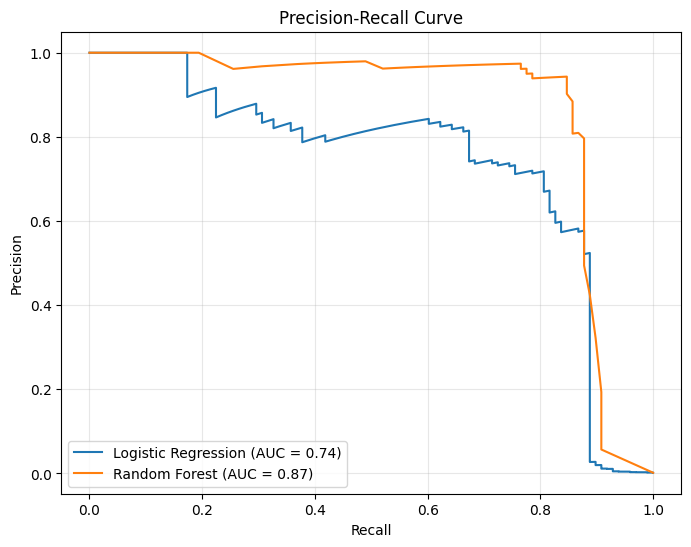

In [ ]:
# precision_recall_curve returns precision and recall at every possible threshold
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_probs)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)

# Plot both curves
plt.figure(figsize=(8, 6))
plt.grid(True, alpha=0.3)
plt.plot(lr_recall, lr_precision, label=f'Logistic Regression (AUC = {auc(lr_recall, lr_precision):.2f})')
plt.plot(rf_recall, rf_precision, label=f'Random Forest (AUC = {auc(rf_recall, rf_precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 6. ROC Curve

ROC curve plots the True Positive Rate (recall) against the False Positive Rate
at every possible threshold

- **True Positive Rate** — actual fraud did we catch
- **False Positive Rate** — legitimate transactions did we wrongly flag

**The dashed line** Both models sit far above this line, confirming they are significantly better than random guessing

ROC is misleading on imbalanced data —
it makes both models look almost equally good when Random Forest is clearly superior

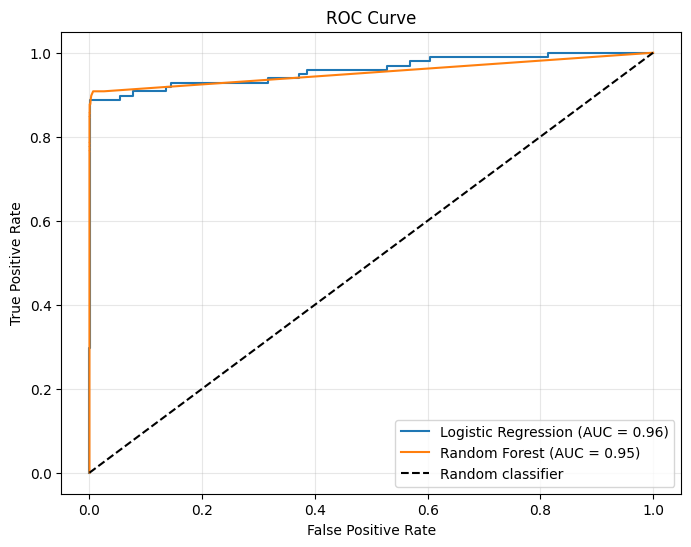

In [ ]:
# roc_curve returns false positive rate and true positive rate at every threshold
lr_false_positive_rate, lr_true_positive_rate, _ = roc_curve(y_test, lr_probs)
rf_false_positive_rate, rf_true_positive_rate, _ = roc_curve(y_test, rf_probs)


plt.figure(figsize=(8, 6))
plt.grid(True, alpha=0.3)
plt.plot(lr_false_positive_rate, lr_true_positive_rate, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.plot(rf_false_positive_rate, rf_true_positive_rate, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Threshold Tuning

Random Forest predicts fraud when the probability is above 0.5
lowering this threshold we can catch more fraud at the cost of slightly more false alarms

**Why lower the threshold?**
Fraud detection missing a real fraud case (false negative) is more costly than
a false alarm (false positive)

In [ ]:
# We apply our own threshold manually
# (rf_probs >= threshold) returns True/False for each transaction
# .astype(int) converts True/False to 1/0
threshold = 0.3
predict_rf_custom = (rf_probs >= threshold).astype(int)

print('Random Forest — Default Threshold (0.5)')
print('='*50)
print(classification_report(y_test, predict_rf_test, target_names=['Legitimate', 'Fraud']))

print(f'Random Forest — Custom Threshold (threshold = {threshold})')
print('='*50)
print(classification_report(y_test, predict_rf_custom, target_names=['Legitimate', 'Fraud']))

Random Forest — Default Threshold (0.5)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest — Custom Threshold (threshold = 0.3)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 8. Precision and Recall vs Threshold

chart shows how precision and recall change as we move the threshold

- As threshold **decreases** — recall goes up (catch more fraud) but precision drops (more false alarms)
- As threshold **increases** — precision goes up (fewer false alarms) but recall drops (miss more fraud)


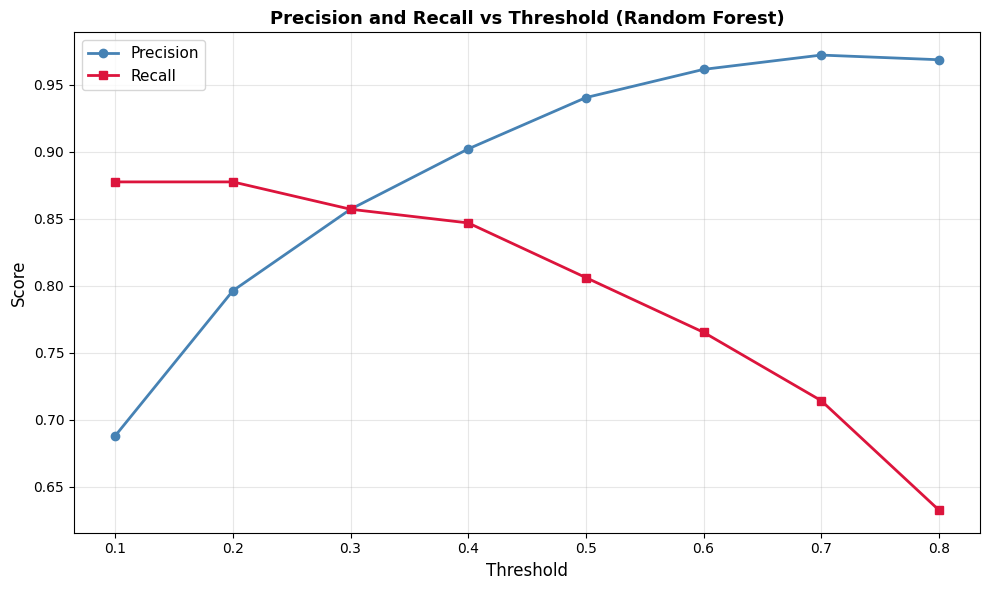

In [ ]:
# Loop through a range of thresholds and record precision and recall at each one
thresholds = np.arange(0.1, 0.9, 0.1)
precisions = []
recalls = []

for t in thresholds:
    # Apply each threshold and calculate metrics
    predict_rf_custom = (rf_probs >= t).astype(int)
    precisions.append(precision_score(y_test, predict_rf_custom))
    recalls.append(recall_score(y_test, predict_rf_custom))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, 'o-', color='steelblue', linewidth=2, markersize=6, label='Precision')
plt.plot(thresholds, recalls, 's-', color='crimson', linewidth=2, markersize=6, label='Recall')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Threshold (Random Forest)',  fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Final Comparison Table

table summarises the performance of all three configurations side by side

In [ ]:
# Build comparison table from actual predictions
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Random Forest"],
    "Threshold": [0.5, 0.5, threshold],
    "Precision": [ precision_score(y_test, predict_lr_test), precision_score(y_test, predict_rf_test), precision_score(y_test, predict_rf_custom)],
    "Recall": [recall_score(y_test, predict_lr_test), recall_score(y_test, predict_rf_test), recall_score(y_test, predict_rf_custom)],
    "F1-Score": [f1_score(y_test, predict_lr_test), f1_score(y_test, predict_rf_test), f1_score(y_test, predict_rf_custom)]
})

# Round to 2 decimal places
results = results.round(2)
print(results.to_string(index=False))


              Model  Threshold  Precision  Recall  F1-Score
Logistic Regression        0.5       0.83    0.64      0.72
      Random Forest        0.5       0.94    0.81      0.87
      Random Forest        0.3       0.97    0.63      0.77
